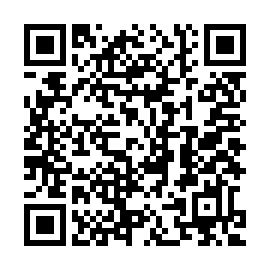

- Em duplas, valendo nota
- Refazer estes exercícios no seu Notebook

# Introdução à manipulação de dados em Pandas

- A biblioteca pandas foi desenvolvida para trabalhar com dados estruturados, ou seja, dados dispostos em linhas e colunas.
- Os dados podem estar gravados em arquivos, em páginas web, em APIs, em outros softwares, em object stores (sistemas de armazenamento em cloud) ou em bancos de dados.
- Para todas essas origens (e até mais), a biblioteca possui métodos capazes de fazer a leitura dos dados e carregar em um DataFrame.
- Todos os métodos capazes de fazer a leitura dos dados estruturados possuem prefixo pd.read_XXX, onde pd é o apelido dado no momento da importação da biblioteca, e XXX é o restante da sintaxe do método.
- Além de fazer a leitura a biblioteca possui diversos métodos capazes de escrever o DataFrame em um arquivo, em um banco ou ainda simplesmente copiar para a área de transferência do sistema operacional.

In [1]:
import pandas as pd

### Lê um arquivo CSV de um endereço na Internet

Primeiro usando o SO:

In [6]:
! wget https://people.sc.fsu.edu/~jburkardt/data/csv/cities.csv

--2023-10-29 22:59:14--  https://people.sc.fsu.edu/~jburkardt/data/csv/cities.csv
Resolving people.sc.fsu.edu (people.sc.fsu.edu)... 144.174.0.22
Connecting to people.sc.fsu.edu (people.sc.fsu.edu)|144.174.0.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8402 (8.2K) [text/csv]
Saving to: ‘cities.csv.2’

cities.csv.2        100%[===================>]   8.21K  --.-KB/s    in 0s      

2023-10-29 22:59:14 (64.3 MB/s) - ‘cities.csv.2’ saved [8402/8402]



In [5]:
! cat cities.csv | head

"LatD", "LatM", "LatS", "NS", "LonD", "LonM", "LonS", "EW", "City", "State"
   41,    5,   59, "N",     80,   39,    0, "W", "Youngstown", OH
   42,   52,   48, "N",     97,   23,   23, "W", "Yankton", SD
   46,   35,   59, "N",    120,   30,   36, "W", "Yakima", WA
   42,   16,   12, "N",     71,   48,    0, "W", "Worcester", MA
   43,   37,   48, "N",     89,   46,   11, "W", "Wisconsin Dells", WI
   36,    5,   59, "N",     80,   15,    0, "W", "Winston-Salem", NC
   49,   52,   48, "N",     97,    9,    0, "W", "Winnipeg", MB
   39,   11,   23, "N",     78,    9,   36, "W", "Winchester", VA
   34,   14,   24, "N",     77,   55,   11, "W", "Wilmington", NC


Usando Pandas:

In [2]:
pd.read_csv("https://people.sc.fsu.edu/~jburkardt/data/csv/cities.csv").head()

,LatD,"""LatM""","""LatS""","""NS""","""LonD""","""LonM""","""LonS""","""EW""","""City""","""State"""
0,41,5,59,"""N""",80,39,0,"""W""","""Youngstown""",OH
1,42,52,48,"""N""",97,23,23,"""W""","""Yankton""",SD
2,46,35,59,"""N""",120,30,36,"""W""","""Yakima""",WA
3,42,16,12,"""N""",71,48,0,"""W""","""Worcester""",MA
4,43,37,48,"""N""",89,46,11,"""W""","""Wisconsin Dells""",WI


### Eliminia duplicados

In [7]:
data = {
    "A": ["TeamA", "TeamB", "TeamB", "TeamC", "TeamA"],
    "B": [50, 40, 40, 30, 50],
    "C": [True, False, False, False, True]
}

df = pd.DataFrame(data)

display(df.drop_duplicates())

,A,B,C
0,TeamA,50,True
1,TeamB,40,False
3,TeamC,30,False


## Cria nova coluna

No dataframe anterior

In [8]:
df["D"] = ["a", "b", "c", "d", "e"]

In [9]:
df

,A,B,C,D
0,TeamA,50,True,a
1,TeamB,40,False,b
2,TeamB,40,False,c
3,TeamC,30,False,d
4,TeamA,50,True,e


### Lê um arquivo JSON de um endereço na Internet

In [10]:
df_selic = pd.read_json("https://api.bcb.gov.br/dados/serie/bcdata.sgs.11/dados?formato=json")
df_selic.head()

,data,valor
0,04/06/1986,0.065041
1,05/06/1986,0.067397
2,06/06/1986,0.066740
3,09/06/1986,0.068247
4,10/06/1986,0.067041


In [11]:
df_selic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9376 entries, 0 to 9375
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   data    9376 non-null   object 
 1   valor   9376 non-null   float64
dtypes: float64(1), object(1)
memory usage: 146.6+ KB


### Acrescenta uma coluna com data

In [12]:
from datetime import date

In [13]:
data_extracao = date.today()
df_selic['data_extracao'] = data_extracao

In [14]:
df_selic.head()

,data,valor,data_extracao
0,04/06/1986,0.065041,2023-10-29
1,05/06/1986,0.067397,2023-10-29
2,06/06/1986,0.066740,2023-10-29
3,09/06/1986,0.068247,2023-10-29
4,10/06/1986,0.067041,2023-10-29


Mostra a estrutura do dataframe:

In [ ]:
df_selic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9348 entries, 0 to 9347
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data           9348 non-null   object 
 1   valor          9348 non-null   float64
 2   data_extracao  9348 non-null   object 
dtypes: float64(1), object(2)
memory usage: 219.2+ KB


As 2 colunas de data são do tipo "object".

## to_datetime() e astype()

Convertendo a coluna `data` para o formato datetime64 do pandas. "[ns]" significa nano segundos.

In [15]:
df_selic['data'] = pd.to_datetime(df_selic['data'], dayfirst=True)

In [16]:
df_selic.head()

,data,valor,data_extracao
0,1986-06-04,0.065041,2023-10-29
1,1986-06-05,0.067397,2023-10-29
2,1986-06-06,0.066740,2023-10-29
3,1986-06-09,0.068247,2023-10-29
4,1986-06-10,0.067041,2023-10-29


In [17]:
df_selic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9376 entries, 0 to 9375
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data           9376 non-null   datetime64[ns]
 1   valor          9376 non-null   float64       
 2   data_extracao  9376 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 219.9+ KB


Convertendo a coluna "data_extração" usando o método astype() para fazer conversão de tipo:

In [18]:
df_selic['data_extracao'] = df_selic['data_extracao'].astype('datetime64[ns]')

In [19]:
df_selic.head()

,data,valor,data_extracao
0,1986-06-04,0.065041,2023-10-29
1,1986-06-05,0.067397,2023-10-29
2,1986-06-06,0.066740,2023-10-29
3,1986-06-09,0.068247,2023-10-29
4,1986-06-10,0.067041,2023-10-29


In [20]:
df_selic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9376 entries, 0 to 9375
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   data           9376 non-null   datetime64[ns]
 1   valor          9376 non-null   float64       
 2   data_extracao  9376 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1)
memory usage: 219.9 KB


## pandas.Series.str

Acrescentando uma coluna e preenchendo com uma string

In [21]:
df_selic["cidade"] = "sao paulo"

In [22]:
df_selic.head()

,data,valor,data_extracao,cidade
0,1986-06-04,0.065041,2023-10-29,sao paulo
1,1986-06-05,0.067397,2023-10-29,sao paulo
2,1986-06-06,0.066740,2023-10-29,sao paulo
3,1986-06-09,0.068247,2023-10-29,sao paulo
4,1986-06-10,0.067041,2023-10-29,sao paulo


Colocando "cidade" em maiúsculas:

In [23]:
df_selic["cidade"] = df_selic["cidade"].str.upper()

In [24]:
df_selic.head()

,data,valor,data_extracao,cidade
0,1986-06-04,0.065041,2023-10-29,SAO PAULO
1,1986-06-05,0.067397,2023-10-29,SAO PAULO
2,1986-06-06,0.066740,2023-10-29,SAO PAULO
3,1986-06-09,0.068247,2023-10-29,SAO PAULO
4,1986-06-10,0.067041,2023-10-29,SAO PAULO


## sort_values()

In [25]:
df_selic.sort_values(by='data', ascending=False, inplace=True)

In [26]:
df_selic.head()

,data,valor,data_extracao,cidade
9375,2023-10-27,0.047279,2023-10-29,SAO PAULO
9374,2023-10-26,0.047279,2023-10-29,SAO PAULO
9373,2023-10-25,0.047279,2023-10-29,SAO PAULO
9372,2023-10-24,0.047279,2023-10-29,SAO PAULO
9371,2023-10-23,0.047279,2023-10-29,SAO PAULO


## reset_index() e set_index()

In [27]:
df_selic.reset_index(drop=True,inplace=True)

In [28]:
df_selic.head()

,data,valor,data_extracao,cidade
0,2023-10-27,0.047279,2023-10-29,SAO PAULO
1,2023-10-26,0.047279,2023-10-29,SAO PAULO
2,2023-10-25,0.047279,2023-10-29,SAO PAULO
3,2023-10-24,0.047279,2023-10-29,SAO PAULO
4,2023-10-23,0.047279,2023-10-29,SAO PAULO


Cria uma lisa com os novos índices:

In [29]:
lista_novo_indice = [f'selic_{indice}' for indice in df_selic.index]

In [30]:
lista_novo_indice[:5]

['selic_0', 'selic_1', 'selic_2', 'selic_3', 'selic_4']

Aplica no dataframe:

In [31]:
df_selic.set_index(keys=[lista_novo_indice], inplace=True)

In [32]:
df_selic.head()

,data,valor,data_extracao,cidade
selic_0,2023-10-27,0.047279,2023-10-29,SAO PAULO
selic_1,2023-10-26,0.047279,2023-10-29,SAO PAULO
selic_2,2023-10-25,0.047279,2023-10-29,SAO PAULO
selic_3,2023-10-24,0.047279,2023-10-29,SAO PAULO
selic_4,2023-10-23,0.047279,2023-10-29,SAO PAULO


## Menor e maior índice: idxmin() e idxmax()

In [ ]:
df_selic['valor'].idxmin()

'selic_8402'

In [ ]:
df_selic['valor'].idxmax()

'selic_8419'

## Seleciona um ou vários registros: loc()

In [ ]:
df_selic.loc['selic_0']

data             2023-09-18 00:00:00
valor                       0.049037
data_extracao    2023-09-19 00:00:00
cidade                     SAO PAULO
Name: selic_0, dtype: object

In [ ]:
df_selic.loc[['selic_0', 'selic_4', 'selic_200']]

,data,valor,data_extracao,cidade
selic_0,2023-09-18,0.049037,2023-09-19,SAO PAULO
selic_4,2023-09-12,0.049037,2023-09-19,SAO PAULO
selic_200,2022-12-01,0.050788,2023-09-19,SAO PAULO


In [ ]:
df_selic.loc[:'selic_3']

,data,valor,data_extracao,cidade
selic_0,2023-09-18,0.049037,2023-09-19,SAO PAULO
selic_1,2023-09-15,0.049037,2023-09-19,SAO PAULO
selic_2,2023-09-14,0.049037,2023-09-19,SAO PAULO
selic_3,2023-09-13,0.049037,2023-09-19,SAO PAULO


Seleciona registros e coluna:

In [ ]:
df_selic.loc[['selic_0', 'selic_4', 'selic_200'], 'valor']

selic_0      0.049037
selic_4      0.049037
selic_200    0.050788
Name: valor, dtype: float64

## Seleção usando valores booleanos

In [ ]:
teste = df_selic['data'] >= pd.to_datetime('2020-01-01')

In [ ]:
teste[:3]

selic_0    True
selic_1    True
selic_2    True
Name: data, dtype: bool

In [ ]:
teste = (df_selic['valor'] < 0.01) | (df_selic['data'] >= pd.to_datetime('2020-01-01'))

In [ ]:
df_selic[teste].head()

,data,valor,data_extracao,cidade
selic_0,2023-09-18,0.049037,2023-09-19,SAO PAULO
selic_1,2023-09-15,0.049037,2023-09-19,SAO PAULO
selic_2,2023-09-14,0.049037,2023-09-19,SAO PAULO
selic_3,2023-09-13,0.049037,2023-09-19,SAO PAULO
selic_4,2023-09-12,0.049037,2023-09-19,SAO PAULO


## Banco de dados

- <https://colab.research.google.com/github/tensorflow/io/blob/master/docs/tutorials/postgresql.ipynb>
- <https://thivyapriyaa.medium.com/setting-up-postgresql-on-google-colab-4d02166939fc>

In [79]:
%%capture
# Install postgresql server
! sudo apt -y -qq update
! sudo apt -y -qq install postgresql
! sudo service postgresql start

In [80]:
# Setup a password `secret` for username `postgres`
!sudo -u postgres psql -U postgres -c "ALTER USER postgres PASSWORD 'secret';"

ALTER ROLE


In [81]:
# Setup a database with name `sampledb` to be used
!sudo -u postgres psql -U postgres -c 'DROP DATABASE IF EXISTS test;'

DROP DATABASE


In [82]:
!sudo -u postgres psql -U postgres -c 'CREATE DATABASE test;'

CREATE DATABASE


In [83]:
import psycopg2

In [84]:
conn = psycopg2.connect(host="localhost",
                        database="test",
                        user="postgres",
                        password="secret")

In [85]:
conn

<connection object at 0x7e4f20c525c0; dsn: 'user=postgres password=xxx dbname=test host=localhost', closed: 0>

In [86]:
cur = conn.cursor()

In [87]:
cur.execute("""
CREATE TABLE Employee
(
    ID INT   PRIMARY KEY NOT NULL,
    NAME TEXT NOT NULL,
    EMAI TEXT NOT NULL
)
""")

In [74]:
conn.commit()

In [75]:
cur.execute("""
INSERT INTO Employee (ID,NAME,EMAI) VALUES
(1,'Alan Walker','awalker@gmail.com'),
(2,'Steve Jobs','sjobs@gmail.com')
""")

In [76]:
conn.commit()

In [77]:
cur.execute("SELECT * FROM Employee")
rows = cur.fetchall()
for data in rows:
    print("ID :" + str(data[0]))
    print("NAME :" + data[1])
    print("EMAIL :" + data[2])

ID :1
NAME :Alan Walker
EMAIL :awalker@gmail.com
ID :2
NAME :Steve Jobs
EMAIL :sjobs@gmail.com


In [78]:
conn.close()